In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv('dirty_cafe_sales.csv')
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
# Converting types to appropriate types
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9667 non-null   object        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   object        
 6   Location          6735 non-null   object        
 7   Transaction Date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [7]:
# Fill missing numerical values with the mean
num_imputer = SimpleImputer(strategy='mean')
# use the correct column name 'Price Per Unit' and assign a 1D array back to the column
df['Price Per Unit'] = num_imputer.fit_transform(df[['Price Per Unit']])[:, 0]
df['Quantity'] = num_imputer.fit_transform(df[['Quantity']])[:, 0]

In [8]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity               0
Price Per Unit         0
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [9]:
df['Total Spent'] = num_imputer.fit_transform(df[['Total Spent']])[:, 0]

In [10]:
# Fill missing categorical values with 'Unknown'
df['Location'].fillna('Unknown', inplace=True)
df['Payment Method'].fillna('Unknown', inplace=True)

C:\Users\mahes\AppData\Local\Temp\ipykernel_13980\4244806013.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Location'].fillna('Unknown', inplace=True)
C:\Users\mahes\AppData\Local\Temp\ipykernel_13980\4244806013.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [11]:
df.isna().sum()

Transaction ID        0
Item                333
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

In [12]:
# Correct inconsistencies in 'Payment_Method'
df['Payment Method'] = df['Payment Method'].str.strip().str.lower()
df['Payment Method'] = df['Payment Method'].replace({'creditcard': 'credit card'})
df['Payment Method'].value_counts()

Payment Method
unknown           2872
digital wallet    2291
credit card       2273
cash              2258
error              306
Name: count, dtype: int64

In [14]:
# Fill missing values in 'item' using KNN Imputer based on 'Price Per Unit' and 'Quantity'
# First, we need to encode 'Product' to numerical values for KNN Imputer
df['Item'] = df['Item'].factorize()[0]
knn_imputer = KNNImputer(n_neighbors=5)
df[['Item', 'Quantity', 'Price Per Unit']] = knn_imputer.fit_transform(df[['Item', 'Quantity', 'Price Per Unit']])
df['Item'] = df['Item'].astype(int).astype(str)
df['Item'].value_counts()

Item
9     1171
0     1165
3     1148
1     1139
6     1131
4     1096
2     1092
10    1089
5      344
7      333
8      292
Name: count, dtype: int64

In [15]:
# Fill 'Transaction Date' missing values with the most frequent date
# SimpleImputer does not accept datetime64; use pandas mode to get the most frequent date
most_freq_date = df['Transaction Date'].mode(dropna=True)
if not most_freq_date.empty:
    df['Transaction Date'].fillna(most_freq_date[0], inplace=True)

C:\Users\mahes\AppData\Local\Temp\ipykernel_13980\2159946769.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction Date'].fillna(most_freq_date[0], inplace=True)


In [16]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [18]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [17]:
# checking dupilicates
df.duplicated().sum()

0

In [22]:
df.drop(columns=['Transaction ID'], inplace=True)

In [23]:
df.isnull().sum()

Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [47]:
df.to_csv('cleaned_cafe_sales.csv', index=False)

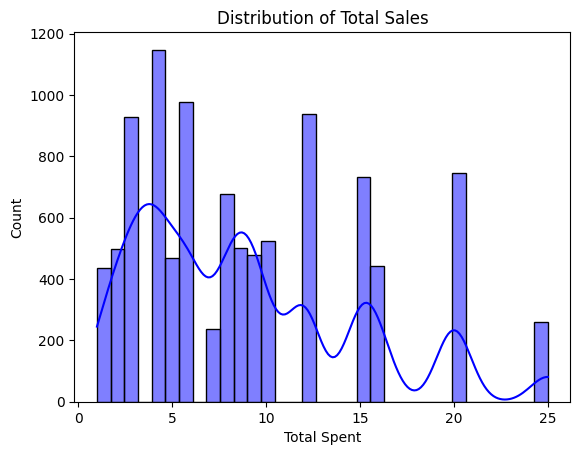

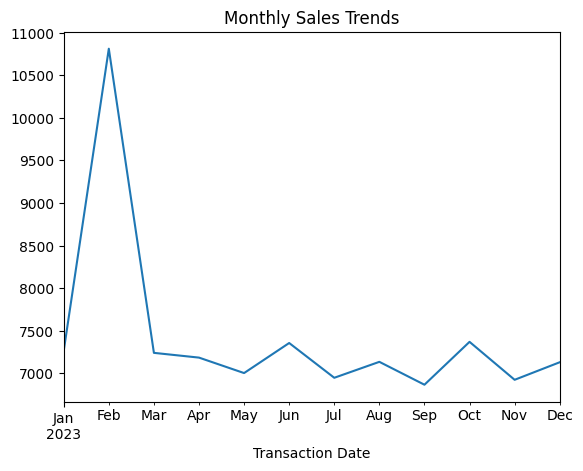

In [19]:
# Plot sales distribution
sns.histplot(df['Total Spent'], kde=True, color='blue')
plt.title('Distribution of Total Sales')
plt.show()

# Analyze sales trends over time
df['TransactionDate'] = pd.to_datetime(df['Transaction Date'])
df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum().plot(kind='line')
plt.title('Monthly Sales Trends')
plt.show()

In [20]:
# Install profiling package (run once in the notebook) #Pandas Profiling, now known as ydata-profiling and sweetviz,pygwalker, etc.
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\mahes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:


from ydata_profiling import ProfileReport

# Use the already-loaded dataframe `df` from earlier cells
profile = ProfileReport(df, title="Pandas Profiling Report", explorative=True)

# Save the report to an HTML file
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  5.68it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [1]:
%pip install pygwalker

  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached astor-0.8.1-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached backoff-2.2.1-py3-none-any.whl.metadata (14 kB)
  Using cached monotonic-1.6-py2.py3-none-any.whl.metadata (1.5 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
   ---------------------------------------- 0.0/4.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.5 MB 435.7 kB/s eta 0:00:11
   ---------------------------------------- 0.0/4.5 MB 495.5 kB/s eta 0:00:09
    --------------------------------------- 0.1/4.5 MB 573.4 kB/s eta 0:00:08
   - -------------------------------------- 0.1/4.5 MB 656.4 kB/s eta 0:00:07
   - -------------------------------------- 0.2/4.5 MB 704.6


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\mahes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import pygwalker as pyg

In [3]:
df = pd.read_csv('cleaned_cafe_sales.csv')
walker = pyg.walk(df)

Box(children=(HTML(value='\n<div id="ifr-pyg-000641a27763a3f3vALHpuQnNidTwz68" style="height: auto">\n    <hea…